Congrats! You just graduated UVA's BSDS program and got a job working at a movie studio in Hollywood. 

Your boss is the head of the studio and wants to know if they can gain a competitive advantage by predicting new movies that might get high imdb scores (movie rating). 

You would like to be able to explain the model to mere mortals but need a fairly robust and flexible approach so you've chosen to use decision trees to get started. 

In doing so, similar to  great data scientists of the past you remembered the excellent education provided to you at UVA in a undergrad data science course and have outline 20ish steps that will need to be undertaken to complete this task. As always, you will need to make sure to #comment your work heavily. 

 Footnotes: 
-	You can add or combine steps if needed
-	Also, remember to try several methods during evaluation and always be mindful of how the model will be used in practice.
- Make sure all your variables are the correct type (factor, character,numeric, etc.)

## Import the libraries and the dataset

In [414]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import graphviz 

from sklearn.model_selection import train_test_split,GridSearchCV,RepeatedStratifiedKFold
from sklearn import metrics
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.metrics import roc_curve, auc

In [415]:
#1. Load the data
#Sometimes need to set the working directory back out of a folder that we create a file in

#import os
#os.listdir()
#print(os.getcwd())
#os.chdir('c:\\Users\\Brian Wright\\Documents\\3001Python\\DS-3001')

movie_metadata=pd.read_csv("../data/movie_metadata.csv")

## Check for missing variables and correct as needed. Once you've completed the cleaning again create a function that will do this for you in the future. In the submission, include only the function and the function call.

In [416]:
movie_metadata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   color                      5024 non-null   object 
 1   director_name              4939 non-null   object 
 2   num_critic_for_reviews     4993 non-null   float64
 3   duration                   5028 non-null   float64
 4   director_facebook_likes    4939 non-null   float64
 5   actor_3_facebook_likes     5020 non-null   float64
 6   actor_2_name               5030 non-null   object 
 7   actor_1_facebook_likes     5036 non-null   float64
 8   gross                      4159 non-null   float64
 9   genres                     5043 non-null   object 
 10  actor_1_name               5036 non-null   object 
 11  movie_title                5043 non-null   object 
 12  num_voted_users            5043 non-null   int64  
 13  cast_total_facebook_likes  5043 non-null   int64

In [417]:
def data_cleaning(df, column):
    # convert object columns to categorical
    cat = df.select_dtypes(include=['object']).columns.tolist()
    df[cat] = df[cat].astype('category')

    # drop irrelevant columns
    df = df.drop(column, axis=1)
    
    # drop NA
    df = df.dropna()

    return df

movie_metadata = data_cleaning(movie_metadata,['movie_title','plot_keywords','movie_imdb_link','actor_2_name','actor_3_name','genres'])

In [418]:
#use one hot encoding for other categorical variables
encoder = OneHotEncoder(sparse_output=False)

In [419]:
movie_metadata['imdb_score']=movie_metadata['imdb_score'].astype('float64')

In [420]:
# Categorize imdb_score into three classes
movie_metadata["imdb_score"] = movie_metadata["imdb_score"].apply(
    lambda x: "high" if x >= 7.5 else "low"
)

#print(movie_metadata["imdb_score"].value_counts())

movie_metadata["imdb_score"] = OrdinalEncoder().fit_transform(movie_metadata[['imdb_score']])

#print(movie_metadata["imdb_score"].value_counts())

In [421]:
## encode directors
dir_val=movie_metadata['director_name'].value_counts().nlargest(10).index

#print(dir_val)

movie_metadata['director_name']=movie_metadata['director_name'].apply(
    lambda x: 'Famous' if x in dir_val else 'Other')

#print(movie_metadata['director_name'].value_counts())

#one hot encode
dir_encoded = encoder.fit_transform(movie_metadata[["director_name"]])
dir_1h = pd.DataFrame(
    dir_encoded,
    columns=encoder.get_feature_names_out(['director_name']),
    index=movie_metadata.index
)

movie_metadata = pd.concat([movie_metadata.drop(columns=['director_name']), dir_1h], axis=1)

#print(movie_metadata["director_name"].value_counts())

In [422]:
## encode title_year
movie_metadata["title_year"] = movie_metadata["title_year"].apply(
    lambda x: "old" if x < 2000 else "new" if x >= 2010 else "middle"
)

title_encoded=encoder.fit_transform(movie_metadata[["title_year"]])
title_1h = pd.DataFrame(
    title_encoded,
    columns=encoder.get_feature_names_out(['title_year']),
    index=movie_metadata.index
)

movie_metadata = pd.concat([movie_metadata.drop(columns=['title_year']), title_1h], axis=1)

In [423]:
## encode first actor
act_10 = list(movie_metadata['actor_1_name'].value_counts().nlargest(10).index)

#print(act_10)

# Create a new column so you can compare after
movie_metadata['actor_1_name'] = movie_metadata['actor_1_name'].apply(
    lambda x: 'Famous' if x in act_10 else 'Other'
)

#print(movie_metadata['actor_1_name'].value_counts())

act_encoded = encoder.fit_transform(movie_metadata[["actor_1_name"]])
act_1h = pd.DataFrame(
    act_encoded,
    columns=encoder.get_feature_names_out(['actor_1_name']),
    index=movie_metadata.index
)

movie_metadata = pd.concat([movie_metadata.drop(columns=['actor_1_name']), act_1h], axis=1)
#print(movie_metadata['actor_1_name'])

In [424]:
## encode country
count10=movie_metadata['country'].value_counts().nlargest(10)
#print(count10)

movie_metadata['country']=movie_metadata['country'].apply(
    lambda x: 'Big Country Producer' if x in count10 else 'Other'
)
#print(movie_metadata['country'].value_counts())

count_encoded = encoder.fit_transform(movie_metadata[["country"]])
count_1h = pd.DataFrame(
    count_encoded,
    columns=encoder.get_feature_names_out(['country']),
    index=movie_metadata.index
)

movie_metadata = pd.concat([movie_metadata.drop(columns=['country']), count_1h], axis=1)
#print(movie_metadata['actor_1_name'])

In [425]:
## encode content rating
#print(movie_metadata['content_rating'].value_counts())
movie_metadata['content_rating']=movie_metadata['content_rating'].apply(
    lambda x: 'PG-13' if x == 'PG-13' else 'R' if x == 'R' else 'Other')

#print(movie_metadata['content_rating'].value_counts())

cont_encoded = encoder.fit_transform(movie_metadata[["content_rating"]])
cont_1h = pd.DataFrame(
    cont_encoded,
    columns=encoder.get_feature_names_out(['content_rating']),
    index=movie_metadata.index
)

movie_metadata = pd.concat([movie_metadata.drop(columns=['content_rating']), cont_1h], axis=1)

In [426]:
## encode language
lang10=movie_metadata['language'].value_counts().nlargest(10)
#print(lang10)

movie_metadata['language']=movie_metadata['language'].apply(
    lambda x: 'English' if x == 'English' else 'French' if x == 'French' else 'Other'
)
#print(movie_metadata['language'].value_counts())

#movie_metadata[['language']]=OneHotEncoder().fit_transform(movie_metadata[['language']])
#print(movie_metadata['language'].value_counts())

language_encoded = encoder.fit_transform(movie_metadata[['language']])

language_1h = pd.DataFrame(
    language_encoded,
    columns=encoder.get_feature_names_out(['language']),
    index=movie_metadata.index
)

movie_metadata = pd.concat([movie_metadata.drop(columns=['language']), language_1h], axis=1)

In [427]:
## encode color
#print(movie_metadata['color'].value_counts())
movie_metadata['color']=movie_metadata['color'].apply(
    lambda x: 'Color' if x == 'Color' else 'Black and White')
#movie_metadata[['color']]=OneHotEncoder().fit_transform(movie_metadata[['color']])
#print(movie_metadata['color'].value_counts())

color_encoded = encoder.fit_transform(movie_metadata[['color']])

color_1h = pd.DataFrame(
    color_encoded,
    columns=encoder.get_feature_names_out(['color']),
    index=movie_metadata.index
)

movie_metadata = pd.concat([movie_metadata.drop(columns=['color']), color_1h], axis=1)

## 4 Guess what, you don't need to scale the data, because DTs don't require this to be done, they make local greedy decisions...keeps getting easier, go to the next step.

## 5 Determine the baserate or prevalence for the classifier, what does this number mean?

In [428]:
#calculate the prevalence
print(movie_metadata['imdb_score'].value_counts()) #633/3122
print('The prevalence is: ',635/(2835+635+299))

imdb_score
1.0    3134
0.0     635
Name: count, dtype: int64
The prevalence is:  0.16847970283894934


This number means that the possibility of predicting a movie with a high imdb score is 0.169.

## 6 Split your data into test, tune, and train. (80/10/10)

In [429]:
X= movie_metadata.drop(columns=['imdb_score'])
y= movie_metadata['imdb_score']

In [430]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.70, stratify= y, random_state=21)
X_tune, X_test, y_tune, y_test = train_test_split(X_test,y_test,  train_size = 0.50,stratify= y_test, random_state=49)

## 7 Create the kfold object for cross validation.

In [431]:
from sklearn.model_selection import RepeatedStratifiedKFold

kf = RepeatedStratifiedKFold(n_splits=10,n_repeats =5, random_state=42)

## 8 Create the scoring metric you will use to evaluate your model and the max depth hyperparameter 

In [432]:
scoring = ['roc_auc','recall','balanced_accuracy']
param={"max_depth" : [1,2,3,4,5,6,7,8,9,10,11]}

## 9 Build the classifier object 

In [433]:
cl= DecisionTreeClassifier(random_state=1000)

## 10 Use the kfold object and the scoring metric to find the best hyperparameter value for max depth via the grid search method.

In [434]:
#Set up search for best decision tree classifier estimator across all of our folds based on roc_auc
search = GridSearchCV(cl, param, scoring=scoring, n_jobs=-1, cv=kf,refit='roc_auc')

## 11 Fit the model to the training data.

In [435]:
#execute search on our training data, this may take a few seconds ...
model = search.fit(X_train, y_train)

In [436]:
movie_metadata

,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_1_facebook_likes,gross,num_voted_users,cast_total_facebook_likes,facenumber_in_poster,num_user_for_reviews,...,country_Big Country Producer,country_Other,content_rating_Other,content_rating_PG-13,content_rating_R,language_English,language_French,language_Other,color_Black and White,color_Color
0,723.0,178.0,0.0,855.0,1000.0,760505847.0,886204,4834,0.0,3054.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
1,302.0,169.0,563.0,1000.0,40000.0,309404152.0,471220,48350,0.0,1238.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
2,602.0,148.0,0.0,161.0,11000.0,200074175.0,275868,11700,1.0,994.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
3,813.0,164.0,22000.0,23000.0,27000.0,448130642.0,1144337,106759,0.0,2701.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
5,462.0,132.0,475.0,530.0,640.0,73058679.0,212204,1873,1.0,738.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5026,81.0,110.0,107.0,45.0,576.0,136007.0,3924,776,1.0,39.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
5027,64.0,90.0,397.0,0.0,5.0,673780.0,4555,5,0.0,26.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
5033,143.0,77.0,291.0,8.0,291.0,424760.0,72639,368,0.0,371.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
5035,56.0,81.0,0.0,6.0,121.0,2040920.0,52055,147,0.0,130.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0


## 12 What is the best depth value?

In [437]:
#Retrieve the best estimator out of all parameters passed, based on highest roc_auc
best = model.best_estimator_
print(best)
print(model.best_score_)
#print(best.score(X_train, y_train))

DecisionTreeClassifier(max_depth=5, random_state=1000)
0.8307601597125259


The best depth value is 5.

## 13 Print out the model

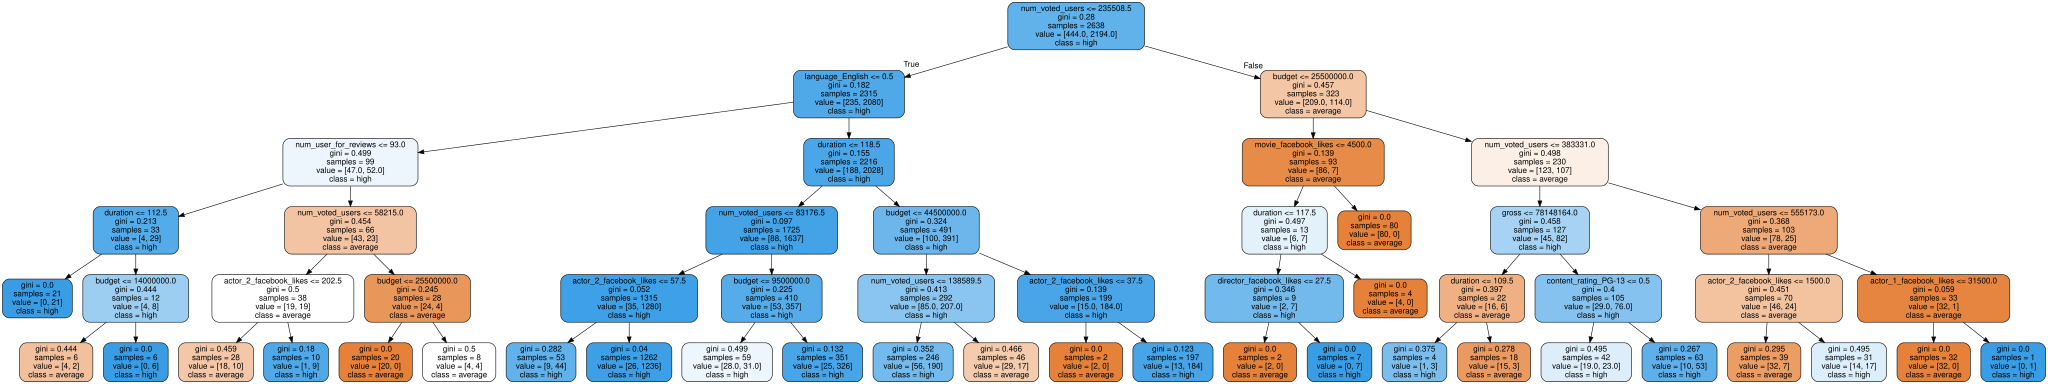

In [438]:
dot_data = export_graphviz(best, out_file =None,
               feature_names =X.columns, #feature names from dataset
               filled=True, 
                rounded=True, 
                class_names = ['average','high']) #classification labels 
               
graph=graphviz.Source(dot_data)
graph

## 14 View the results, comment on how the model performed using several evaluation metrics. (Use multiple methods)

### ROC and AUC

In [ ]:
#What about the specific scores (roc_auc, recall, balanced_accuracy)? Let's try and extract them to see what we are working with ...
#print(model.cv_results_) #This is a dictionary and in order to extract info we need the keys

{'mean_fit_time': array([0.00897694, 0.00694136, 0.0086338 , 0.01088874, 0.01341181,
       0.01438343, 0.01647586, 0.0184893 , 0.02153208, 0.02185011,
       0.02266306]), 'std_fit_time': array([0.00968628, 0.00331746, 0.00218118, 0.00306774, 0.00368263,
       0.00332453, 0.0030293 , 0.00267391, 0.00361574, 0.00262976,
       0.00323398]), 'mean_score_time': array([0.00821759, 0.0043855 , 0.00396585, 0.00448874, 0.00456769,
       0.0052396 , 0.00476942, 0.00405975, 0.0039636 , 0.00429824,
       0.00387705]), 'std_score_time': array([0.00594145, 0.00246468, 0.00194491, 0.00242666, 0.0022771 ,
       0.00225294, 0.00207688, 0.00228865, 0.00183156, 0.00239256,
       0.00184396]), 'param_max_depth': masked_array(data=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
             mask=[False, False, False, False, False, False, False, False,
                   False, False, False],
       fill_value=999999), 'params': [{'max_depth': 1}, {'max_depth': 2}, {'max_depth': 3}, {'max_depth': 4}, {'max_dep

In [440]:
#Let's extract these scores, using our function!

#Scores: 

auc = model.cv_results_['mean_test_roc_auc']
recall= model.cv_results_['mean_test_recall']
bal_acc= model.cv_results_['mean_test_balanced_accuracy']

SDauc = model.cv_results_['std_test_roc_auc']
SDrecall= model.cv_results_['std_test_recall']
SDbal_acc= model.cv_results_['std_test_balanced_accuracy']

#Parameter:
depth= np.unique(model.cv_results_['param_max_depth']).data

#Build DataFrame:
final_model = pd.DataFrame(list(zip(depth, auc, recall, bal_acc,SDauc,SDrecall,SDbal_acc)),
               columns =['depth','auc','recall','bal_acc','aucSD','recallSD','bal_accSD'])

#Let's take a look
final_model.style.hide(axis='index')

depth,auc,recall,bal_acc,aucSD,recallSD,bal_accSD
1,0.706021,0.944577,0.706021,0.039263,0.014480,0.039263
2,0.752221,0.956246,0.667062,0.038592,0.024067,0.052025
3,0.800054,0.963266,0.703653,0.042919,0.014942,0.042882
4,0.826729,0.966365,0.705475,0.042158,0.012886,0.044636
5,0.830760,0.964543,0.704766,0.043019,0.013532,0.040107
6,0.819838,0.953143,0.727890,0.045640,0.014868,0.042608
7,0.787902,0.945942,0.731340,0.045180,0.016340,0.043303
8,0.757268,0.938563,0.739165,0.060454,0.016721,0.042132
9,0.726384,0.934276,0.739199,0.057043,0.017581,0.038651
10,0.722578,0.928351,0.744372,0.054612,0.018682,0.037374


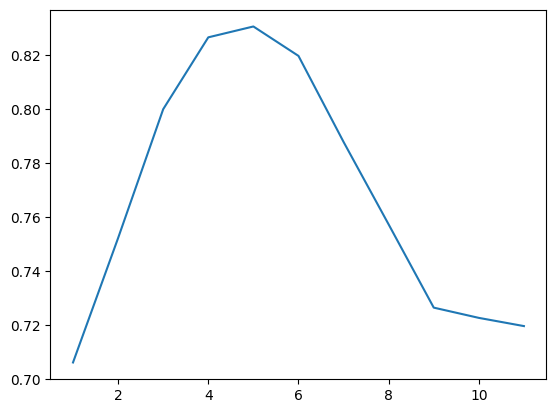

In [441]:
print(plt.plot(final_model.depth,final_model.auc))

From this graph we can see that the model's auc reaches the highest at the depth of 5.

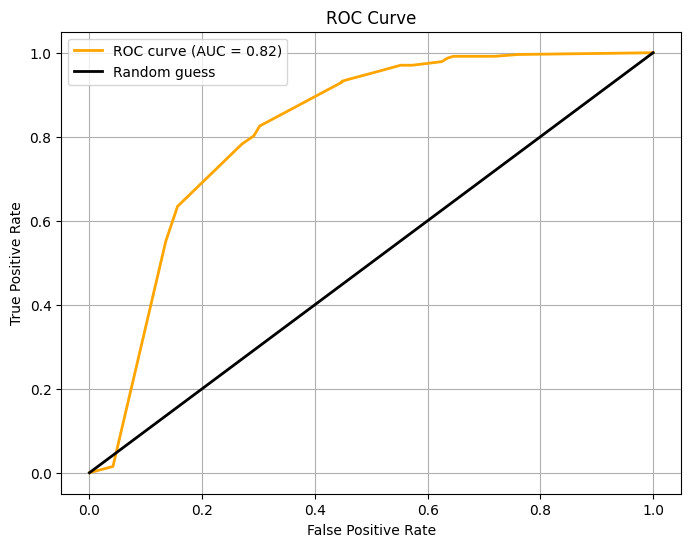

In [442]:
from sklearn.metrics import roc_curve, auc
# Get predicted probabilities for the positive class
y_probs = model.predict_proba(X_test)[:, 1]

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc_score = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='orange', lw=2, label=f'ROC curve (AUC = {roc_auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='-', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

The area under curve of the model is 0.84 on the test data, which falls within the range of 0.8 to 0.9. This means that the model is "good".

### F1 Score

In [443]:
F1_score = metrics.f1_score(y_test, model.predict(X_test),average='weighted')
print(F1_score)

0.8688963062531126


F1-score works better for unbalanced datasets. In this case, the prevalence is 0.2, which means there are way more average imdb-ratings than high ones. Therefore, the F1-score turns out to be useful. An F1-score of 0.87 is very decent, which means the model's ability to predict is good.

### Accuracy

In [444]:
#calculate the accuracy
accuracy = metrics.accuracy_score(y_test, model.predict(X_test))
print(accuracy)

0.8816254416961131


The accuracy of the model is 0.88, which is also a very high number.

## 15 Which variables appear to be contributing the most (variable importance) 

In [445]:
#Variable importance for the best estimator, how much weight does each feature have in determining the classification?
imp=pd.DataFrame(best.feature_importances_,index = X.columns,columns=['importance']).sort_values('importance', ascending=False)
print(imp)

                              importance
num_voted_users                 0.577109
budget                          0.142668
language_English                0.077400
duration                        0.067388
actor_2_facebook_likes          0.039655
num_user_for_reviews            0.033237
gross                           0.019883
movie_facebook_likes            0.017419
content_rating_PG-13            0.011674
director_facebook_likes         0.008357
actor_1_facebook_likes          0.005209
content_rating_R                0.000000
country_Other                   0.000000
content_rating_Other            0.000000
num_critic_for_reviews          0.000000
actor_1_name_Other              0.000000
language_French                 0.000000
language_Other                  0.000000
color_Black and White           0.000000
country_Big Country Producer    0.000000
director_name_Other             0.000000
actor_1_name_Famous             0.000000
title_year_old                  0.000000
title_year_new  

Number of users for reviews is the most important feature.

Axes(0.125,0.11;0.775x0.77)


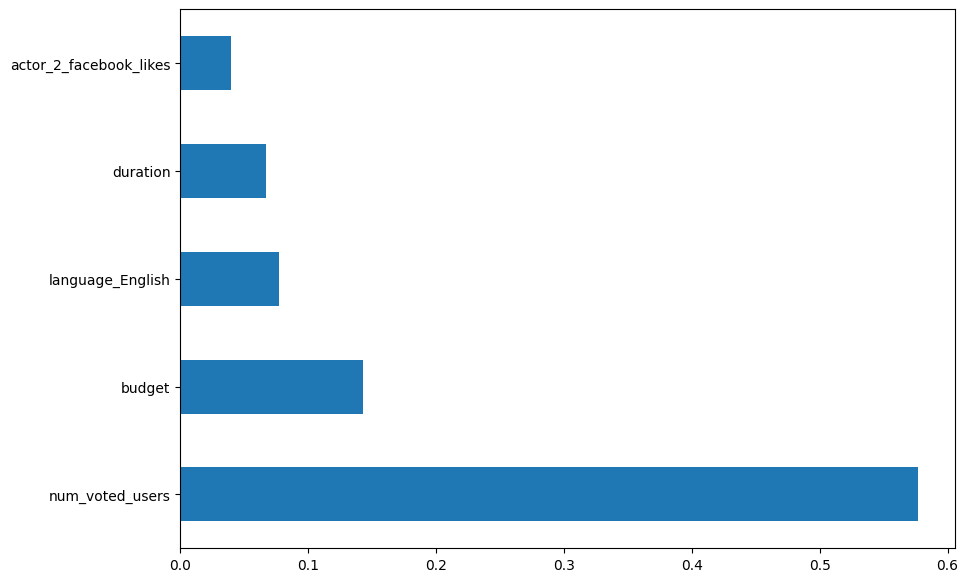

In [446]:
#Graph variable importance
plt.figure(figsize=(10,7))
print(imp.importance.nlargest(5).plot(kind='barh'))

## 16 Use the predict method on the tune data and print out the results. 17 How does the model perform on the tune data?

In [447]:
tune_model = search.fit(X_tune, y_tune)
print(model.best_score_)

0.7242458628841608


## 18 Print out the confusion matrix for the tune data, what does it tell you about the model?

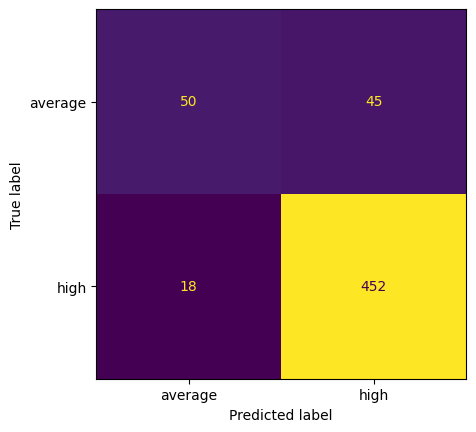

In [448]:
print(ConfusionMatrixDisplay.from_estimator(best,X_tune,y_tune, display_labels = ['average','high'], colorbar=False))

- The true positives rate is 452/(452+45) = 0.91 the true negatives rate is 50/(50+18) = 0.74, the false positives rate is 45/(452+45) = 0.09, and the false negatives rate is 18/(50+18) = 0.26.

- The sensitivity of the model is 452/(452+18) = 0.96, and the specificity is 50/(45+50) = 0.53.

- The model has a high sensitivity, which means the model is good at predicting high imdb-ratings. However, the model has a low specificity, which means the model is not good at predicting average imdb-ratings.

## 19 What are the top 3 movies based on the test set? Which variables are most important in predicting the top 3 movies?

In [449]:
# Predict probabilities
probs = model.predict_proba(X_test)

# Get probability of predicting a high imdb score
X_test_copy = X_test.copy()
X_test_copy['prob_high'] = probs[:, 1]

#re-access the movie_metadata data to acquire the movie titles
movie_title=pd.read_csv("../data/movie_metadata.csv")
X_test_copy=pd.concat([X_test_copy,movie_title['movie_title']],axis=1)

#generate the top 3 movies
top_3 = X_test_copy.sort_values(by='prob_high', ascending=False).head(3)
print(top_3['movie_title'])

2557                    Double Impact 
1522    Mandela: Long Walk to Freedom 
1469                        Abduction 
Name: movie_title, dtype: object


Top 3 Movies Based on Predicted Probability of High Score:
                         movie_title  prob_high
2557                  Double Impact         1.0
1522  Mandela: Long Walk to Freedom         1.0
1469                      Abduction         1.0

Top Predictive Features:
                      importance
num_voted_users         0.519401
gross                   0.104034
num_user_for_reviews    0.076359
duration                0.069774
budget                  0.059846


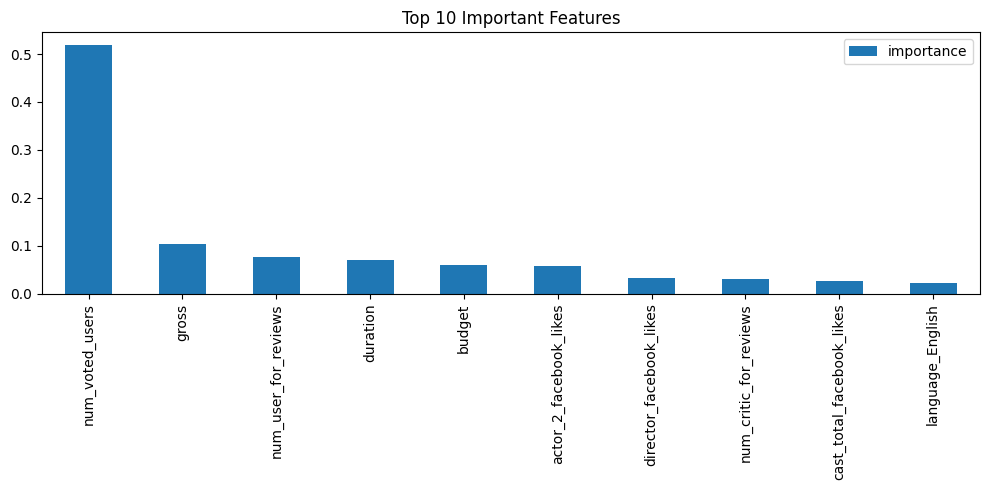

In [454]:
# 4. Predict probabilities on the test set
y_prob = best.predict_proba(X_test)[:, 1]  # Probability for 'high' class

# 5. Attach predictions to original X_test for context
X_test_copy = X_test.copy()
movie_test=pd.read_csv("../data/movie_metadata.csv")
X_test_copy['movie_title'] = movie_test['movie_title']  # Make sure you have the titles
X_test_copy['prob_high'] = y_prob

# 6. Sort and print top 3 movies with highest probability of being 'high'
top_3 = X_test_copy.sort_values(by='prob_high', ascending=False).head(3)
print("Top 3 Movies Based on Predicted Probability of High Score:")
print(top_3[['movie_title', 'prob_high']])

# 7. Feature importance
importances = pd.DataFrame(best.feature_importances_, index=X.columns, columns=['importance']).sort_values('importance', ascending=False)
print("\nTop Predictive Features:")
print(importances.head(5))

# Optional: Plot feature importance
importances.head(10).plot(kind='bar', figsize=(10, 5), title="Top 10 Important Features")
plt.tight_layout()
plt.show()

In [464]:
# Ensure model is already fitted
best.fit(X_tune, y_tune)

# Predict on X_test
y_probs = best.predict_proba(X_test)[:, 1]

# Create clean copy of test set
X_test_copy = X_test.copy().reset_index(drop=True)

# Load movie metadata
movie_metadata = pd.read_csv("../data/movie_metadata.csv")

# Get movie titles that match X_test rows
movie_test = movie_metadata.loc[X_test.index].reset_index(drop=True)

# Attach titles and probabilities
X_test_copy['movie_title'] = movie_test['movie_title'].values
X_test_copy['prob_high'] = y_probs

# Show top 3 movies by high-score probability
top_3 = X_test_copy[['movie_title', 'prob_high']].sort_values(by='prob_high', ascending=False).head(3)

print("🎬 Top 3 Movies Based on Predicted Probability of High Score:")
print(top_3)

🎬 Top 3 Movies Based on Predicted Probability of High Score:
                      movie_title  prob_high
228  I Married a Strange Person!         1.0
101                         Juno         1.0
383                  World War Z         1.0


## 20 Use a different hyperparameter for the grid search function and go through the process above again using the tune set.

In [450]:
final_model.style.hide(axis='index')

depth,auc,recall,bal_acc,aucSD,recallSD,bal_accSD
1,0.706021,0.944577,0.706021,0.039263,0.014480,0.039263
2,0.752221,0.956246,0.667062,0.038592,0.024067,0.052025
3,0.800054,0.963266,0.703653,0.042919,0.014942,0.042882
4,0.826729,0.966365,0.705475,0.042158,0.012886,0.044636
5,0.830760,0.964543,0.704766,0.043019,0.013532,0.040107
6,0.819838,0.953143,0.727890,0.045640,0.014868,0.042608
7,0.787902,0.945942,0.731340,0.045180,0.016340,0.043303
8,0.757268,0.938563,0.739165,0.060454,0.016721,0.042132
9,0.726384,0.934276,0.739199,0.057043,0.017581,0.038651
10,0.722578,0.928351,0.744372,0.054612,0.018682,0.037374


From the previous ROC_AUC analysis, we can see that recall is the best scoring metrics for this model since its score is the highest

In [451]:
print(model.best_score_)

#fit the model with the tune data
model = search.fit(X_tune, y_tune)

#Retrieve the best estimator out of all parameters passed, based on highest roc_auc
best = model.best_estimator_
print('The best params is:',model.best_params_)

#improve the performance of the model by optimizing the parameters
improved_param={"max_depth" : [5]}
improved_scoring = ['recall']
cl = DecisionTreeClassifier(random_state=1000)
improved_search = GridSearchCV(cl, param, scoring=scoring, n_jobs=-1, cv=kf,refit='recall')

#rebuild the model with the new parameters
improved_model = improved_search.fit(X_test, y_test)
improved_score = best.score(X_tune,y_tune)
print(improved_score)

0.7242458628841608
The best params is: {'max_depth': 5}
0.9345132743362832


## 21 Did the model improve with the new hyperparameter search?

The model has an accuracy of 0.93. There is an improvement in the model performance compared with the accuracy of the training data, which was 0.83.

## 22 Using the better model, predict the test data and print out the results.

In [453]:
test_model=improved_search.fit(X_test,y_test)
test_score=best.score(X_test,y_test)
print(test_score)
#print out the result of the model
y_pred = test_model.predict(X_test)
print(y_pred)

0.8498233215547704
[1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1.
 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1.
 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 0. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0.
 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 0. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 0. 1. 1. 0. 1

## 23 Summarize what you learned along the way and make recommendations on how this could be used moving forward, being careful not to over promise.

1. When cleaning data for a decision tree model, make sure to encode useful categorical data. By simply dropping all categorical columns, you are creating bias within the model.
2. In some cases, one-hot encoding may not be necessary. However, it is important to test the model with and without one-hot encoding to see if it improves the model's performance. One-hot encoding can reduce the complexity of the model as it divides the data into multiple columns, eliminating the need for the model to learn the relationship between the categories.

## *What if I drop all the categorical variables?

In [ ]:
movie_metadata2=pd.read_csv("../data/movie_metadata.csv")
cat = movie_metadata2.select_dtypes(include=[object]).columns.tolist()
movie_metadata2=movie_metadata2.drop(cat,axis=1)
movie_metadata2 = movie_metadata2.dropna()
#create the target variable
movie_metadata2['imdb_score'] = movie_metadata2['imdb_score'].apply(
    lambda x: 'high' if x >= 7.5 else 'average'
)
encoder = OneHotEncoder(sparse_output=False)
imdb_encoded = encoder.fit_transform(movie_metadata2[['imdb_score']])
imdb_1h = pd.DataFrame(
    imdb_encoded,
    columns=encoder.get_feature_names_out(['imdb_score']),
    index=movie_metadata2.index
)
movie_metadata2 = pd.concat([movie_metadata2.drop(columns=['imdb_score']), imdb_1h], axis=1)
#train test split
X2 = movie_metadata2.drop(columns=['imdb_score_high','imdb_score_average'])
y2 = movie_metadata2['imdb_score_high']
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, train_size=0.70, stratify=y2, random_state=21)
X2_tune, X2_test, y2_tune, y2_test = train_test_split(X2_test, y2_test, train_size=0.50, stratify=y2_test, random_state=49)
#create the kfold classifer
from sklearn.model_selection import RepeatedStratifiedKFold
kf = RepeatedStratifiedKFold(n_splits=10,n_repeats =5, random_state=42)
#create scoring metrics
scoring = ['roc_auc','recall','balanced_accuracy']
param={"max_depth" : [1,2,3,4,5,6,7,8,9,10,11]}
#create the decision tree classifier
cl= DecisionTreeClassifier(random_state=1000)
#Set up search for best decision tree classifier estimator across all of our folds based on roc_auc
search = GridSearchCV(cl, param, scoring=scoring, n_jobs=-1, cv=kf,refit='roc_auc')
#execute search on our training data
model2 = search.fit(X2_train, y2_train)
#Retrieve the best estimator out of all parameters passed
best2 = model2.best_estimator_
print(best2)
print(best2.score(X2_test,y2_test))

DecisionTreeClassifier(max_depth=5, random_state=1000)
0.8704028021015762


I can still achieve a decent level of accuracy. In fact, it's only slightly lower than the accuracy of the model with all the variables. However, the accuracy doesn't represent the effectiveness of the model. A more robust model can have a lower accuracy but actually include all the factors that are important in predicting the outcome.

## *What if I don't use the one-hot encoding method?

In [ ]:
movie_metadata3=pd.read_csv("../data/movie_metadata.csv")
movie_metadata3=movie_metadata3.dropna()
cat = movie_metadata3.select_dtypes(object).columns.tolist()
movie_metadata3[cat]=movie_metadata3[cat].astype('category')
#create the target variable
movie_metadata3['imdb_score'] = movie_metadata3['imdb_score'].apply(
    lambda x: 'high' if x >= 7.5 else 'average'
)
movie_metadata3['imdb_score']=OrdinalEncoder().fit_transform(movie_metadata3[['imdb_score']])
#print(movie_metadata3['imdb_score'])

# encode directors
dir_val=movie_metadata3['director_name'].value_counts().nlargest(10).index
#print(dir_val)
movie_metadata3['director_name']=movie_metadata3['director_name'].apply(
    lambda x: 'Famous' if x in dir_val else 'Other')
#print(movie_metadata3['director_name'].value_counts())
movie_metadata3['director_name']=OrdinalEncoder().fit_transform(movie_metadata3[['director_name']])
#print(movie_metadata3['director_name'])

#encode title_year
movie_metadata3["title_year"] = movie_metadata3["title_year"].apply(
    lambda x: "old" if x < 2000 else "new" if x >= 2010 else "middle"
)
movie_metadata3["title_year"]=OrdinalEncoder().fit_transform(movie_metadata3[['title_year']])
#print(movie_metadata3['title_year'])

#encode first actor
act_10 = movie_metadata3['actor_1_name'].value_counts().nlargest(10).index
#print(act_10)
movie_metadata3['actor_1_name'] = movie_metadata3['actor_1_name'].apply(
    lambda x: 'Famous' if x in act_10 else 'Other'
)
movie_metadata3['actor_1_name']=OrdinalEncoder().fit_transform(movie_metadata3[['actor_1_name']])

#encode country
count10=movie_metadata3['country'].value_counts().nlargest(10)
#print(count10)
movie_metadata3['country']=movie_metadata3['country'].apply(
    lambda x: 'Big Country Producer' if x in count10 else 'Other'
)
#print(movie_metadata3['country'].value_counts())
movie_metadata3['country']=OrdinalEncoder().fit_transform(movie_metadata3[['country']])
#print(movie_metadata3['country'])

#encode content rating
#print(movie_metadata3['content_rating'].value_counts())
movie_metadata3['content_rating']=movie_metadata3['content_rating'].apply(
    lambda x: 'PG-13' if x == 'PG-13' else 'R' if x == 'R' else 'Other')
#print(movie_metadata3['content_rating'].value_counts())
movie_metadata3['content_rating']=OrdinalEncoder().fit_transform(movie_metadata3[['content_rating']])
#print(movie_metadata3['content_rating'])

#encode language
lang10=movie_metadata3['language'].value_counts().nlargest(10)
#print(lang10)
movie_metadata3['language']=movie_metadata3['language'].apply(
    lambda x: 'English' if x == 'English' else 'French' if x == 'French' else 'Other'
)
#print(movie_metadata3['language'].value_counts())
movie_metadata3['language']=OrdinalEncoder().fit_transform(movie_metadata3[['language']])
#print(movie_metadata3['language'])

#encode color
#print(movie_metadata3['color'].value_counts())
movie_metadata3['color']=movie_metadata3['color'].apply(
    lambda x: 'Color' if x == 'Color' else 'Black and White')
#print(movie_metadata3['color'].value_counts())
movie_metadata3['color']=OrdinalEncoder().fit_transform(movie_metadata3[['color']])
#print(movie_metadata3['color'])

#drop irrelevant columns
movie_metadata3=movie_metadata3.drop(['movie_title','plot_keywords','movie_imdb_link','actor_2_name','actor_3_name','genres'],axis=1)

#train-tune-test split
X3 = movie_metadata3.drop(columns=['imdb_score'])
y3 = movie_metadata3['imdb_score']

X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, train_size=0.70, stratify=y3, random_state=21)
X3_tune, X3_test, y3_tune, y3_test = train_test_split(X3_test, y3_test, train_size=0.50, stratify=y3_test, random_state=49)

#create scoring metrics
scoring = ['roc_auc','recall','balanced_accuracy']
param={"max_depth" : [5]}
#create the decision tree classifier
cl= DecisionTreeClassifier(random_state=1000)
#Set up search for best decision tree classifier estimator across all of our folds based on roc_auc
search = GridSearchCV(cl, param, scoring=scoring, n_jobs=-1, cv=kf,refit='roc_auc')
#execute search on our training data
model3 = search.fit(X3_train, y3_train)
#Retrieve the best estimator out of all parameters passed
best3 = model3.best_estimator_
print(best3)
print(best3.score(X3_test, y3_test))

DecisionTreeClassifier(max_depth=5, random_state=1000)
0.8829787234042553


In [ ]:
print(model.best_score_)

#fit the model with the tune data
model = search.fit(X_tune, y_tune)

#Retrieve the best estimator out of all parameters passed, based on highest roc_auc
best = model.best_estimator_
print('The best params is:',model.best_params_)

#improve the performance of the model by optimizing the parameters
improved_param={"max_depth" : [5]}
improved_scoring = ['recall']
cl = DecisionTreeClassifier(random_state=1000)
improved_search = GridSearchCV(cl, param=improved_param, scoring=improved_scoring, n_jobs=-1, cv=kf,refit='recall')

#rebuild the model with the new parameters
improved_model = improved_search.fit(X_test, y_test)
improved_score = best.score(X_tune,y_tune)
print(improved_score)